**Experiment 3**

In [1]:
# Cell 1 — Install dependencies
!pip -q install opacus==1.4.0 tqdm pandas matplotlib torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 14.0 MB/s eta 0:00:00


In [2]:
# Cell 2 — Imports + reproducibility
import os, math, random
from copy import deepcopy
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt



# Wider alpha grid => avoids "optimal order is the largest alpha" warning
RDP_ALPHAS = (
    [1.01, 1.05] +
    [1.1 + 0.1*i for i in range(0, 90)] +      # 1.1..10.0
    list(range(11, 64)) + [64, 128, 256, 512]
)

def seed_all(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


device: cuda


In [3]:
# Cell 3 — Dataset: Fashion-MNIST + loaders
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.2860,), (0.3530,))
])

train_ds = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

test_loader = DataLoader(test_ds, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
print("train:", len(train_ds), "test:", len(test_ds))


100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 179kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.38MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.2MB/s]

train: 60000 test: 10000


In [4]:
# Cell 4 — PUBLIC set + IID clients (DISJOINT, recommended for paper)
# Public points removed from private client datasets.

NUM_CLASSES = 10
PUBLIC_PER_CLASS = 20      # 200 public points (try 30 => 300)
SAMPLES_PER_CLIENT = 10
CLIENTS_PER_ROUND = 100

def extract_public_per_class(dataset, per_class=20, seed=0):
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    public_idx = []
    for k in range(NUM_CLASSES):
        cls_idx = np.where(targets == k)[0]
        rng.shuffle(cls_idx)
        public_idx.extend(cls_idx[:per_class].tolist())
    return sorted(public_idx)

public_idx = extract_public_per_class(train_ds, per_class=PUBLIC_PER_CLASS, seed=0)

all_train_idx = np.arange(len(train_ds))
mask = np.ones(len(train_ds), dtype=bool)
mask[np.array(public_idx)] = False
avail_idx = all_train_idx[mask]  # private-only indices

NUM_CLIENTS = len(avail_idx) // SAMPLES_PER_CLIENT
private_needed = NUM_CLIENTS * SAMPLES_PER_CLIENT
avail_idx = avail_idx[:private_needed]

def build_iid_clients_from_indices(indices, num_clients, samples_per_client, seed=0):
    rng = np.random.default_rng(seed)
    perm = rng.permutation(indices)
    return [perm[i*samples_per_client:(i+1)*samples_per_client].tolist()
            for i in range(num_clients)]

clients = build_iid_clients_from_indices(avail_idx, NUM_CLIENTS, SAMPLES_PER_CLIENT, seed=0)

print("public samples:", len(public_idx), f"(per_class={PUBLIC_PER_CLASS})")
print("private samples:", len(avail_idx))
print("NUM_CLIENTS:", NUM_CLIENTS, "| samples/client:", SAMPLES_PER_CLIENT, "| clients/round:", CLIENTS_PER_ROUND)
print("q =", CLIENTS_PER_ROUND / NUM_CLIENTS)

public samples: 200 (per_class=20)
private samples: 59800
NUM_CLIENTS: 5980 | samples/client: 10 | clients/round: 100
q = 0.016722408026755852


In [5]:
# Cell 6 — Model + evaluation
class FMNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


In [6]:
# Cell 7 — Tensor-list + flatten helpers
def model_param_list(model):
    return [p for p in model.parameters() if p.requires_grad]

@torch.no_grad()
def zero_like_params(model):
    return [torch.zeros_like(p.data) for p in model_param_list(model)]

@torch.no_grad()
def add_update_(model, update_list, scale=1.0):
    for p, u in zip(model_param_list(model), update_list):
        p.data.add_(u, alpha=scale)

@torch.no_grad()
def add_scaled_list_(dst, src, alpha):
    for d, s in zip(dst, src):
        d.add_(s, alpha=float(alpha))

@torch.no_grad()
def norm_sq_list(tlist):
    s = None
    for t in tlist:
        v = (t*t).sum()
        s = v if s is None else s + v
    return s + 1e-12

@torch.no_grad()
def l2_norm_list(tlist):
    return torch.sqrt(norm_sq_list(tlist))

def sub_list(a, b):
    return [x - y for x, y in zip(a, b)]

@torch.no_grad()
def dot_list(a_list, b_list):
    s = None
    for a, b in zip(a_list, b_list):
        v = (a*b).sum()
        s = v if s is None else s + v
    return s

@torch.no_grad()
def flatten_list(tlist):
    return torch.cat([t.reshape(-1) for t in tlist])

@torch.no_grad()
def unflatten_like(vec, template_list):
    out = []
    idx = 0
    for t in template_list:
        n = t.numel()
        out.append(vec[idx:idx+n].view_as(t))
        idx += n
    return out


In [7]:
# Cell 8 — Local client update (SGD) returns delta = (local - global)
loss_fn = nn.CrossEntropyLoss()

def client_update(global_model, client_indices, lr, momentum,
                  local_epochs=1, batch_size=10,
                  poison=None):
    """
    poison:
      - None: normal training
      - "label_flip": flip labels (LF attack)
    """
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(Subset(train_ds, client_indices),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(local_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            # ----- Label Flipping attack -----
            if poison == "label_flip":
                # simple deterministic flip: shift labels by 1
                y = (y + 1) % NUM_CLASSES

            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta.append((lp.data - gp.data).detach())
    return delta

In [8]:
# Cell 9 — DP accounting (RDP) + sigma search (Opacus-version-proof)
# Purpose: compute epsilon for given noise multiplier(s) and binary-search sigma.

from opacus.accountants.analysis import rdp as rdp_analysis

def _compute_rdp(q, noise_multiplier, steps, orders):
    # Some versions accept kwargs, others positional; support both.
    try:
        return rdp_analysis.compute_rdp(q=q, noise_multiplier=noise_multiplier, steps=steps, orders=orders)
    except TypeError:
        return rdp_analysis.compute_rdp(q, noise_multiplier, steps, orders)

def _get_eps(orders, rdp, delta):
    try:
        eps, _ = rdp_analysis.get_privacy_spent(orders=orders, rdp=rdp, delta=delta)
    except TypeError:
        eps, _ = rdp_analysis.get_privacy_spent(orders, rdp, delta)
    return float(eps)

def epsilon_from_sigma_single(sigma, q, steps, delta):
    rdp = _compute_rdp(q, float(sigma), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp, delta)

def epsilon_from_sigma_two(sig_sel, sig_rel, q, steps, delta):
    rdp1 = _compute_rdp(q, float(sig_sel), int(steps), RDP_ALPHAS)
    rdp2 = _compute_rdp(q, float(sig_rel), int(steps), RDP_ALPHAS)
    return _get_eps(RDP_ALPHAS, rdp1 + rdp2, delta)

def find_sigma_for_target_eps_single(target_eps, q, steps, delta, iters=50):
    lo, hi = 1e-4, 1.0
    while epsilon_from_sigma_single(hi, q, steps, delta) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound. Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        if epsilon_from_sigma_single(mid, q, steps, delta) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)

def find_sigma_rel_for_target_eps_two(target_eps, q, steps, delta, sel_factor=2.0, iters=50):
    # sig_sel = sel_factor * sig_rel
    lo, hi = 1e-4, 1.0
    def E(sig_rel):
        return epsilon_from_sigma_two(sel_factor*sig_rel, sig_rel, q, steps, delta)

    while E(hi) > target_eps:
        hi *= 2.0
        if hi > 1e4:
            raise RuntimeError("Could not find sigma upper bound (two). Reduce steps or increase eps.")
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        if E(mid) > target_eps:
            lo = mid
        else:
            hi = mid
    return float(hi)


In [9]:
# Cell 10 — ALIE attack helpers (constant-z, consistent across f)
# Purpose: ALIE strength does NOT change with Byzantine fraction.

@torch.no_grad()
def alie_attack_from_honest_constz(honest_updates, byz_count, z=2.0, direction=-1.0):
    """
    Returns byz_count malicious updates where:
        mal = mu + direction * z * std   (coordinate-wise)
    z is constant (same for all f).
    """
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates to build ALIE.")

    P = len(honest_updates[0])
    mal = []
    for j in range(P):
        stacked = torch.stack([u[j] for u in honest_updates], dim=0)
        mu = stacked.mean(dim=0)
        sd = stacked.std(dim=0, unbiased=False) + 1e-12
        mal.append(mu + float(direction) * float(z) * sd)

    mal = [t.detach() for t in mal]
    return [[t.clone() for t in mal] for _ in range(byz_count)]


In [10]:
# Cell 10.5 — LF + Fang/AGR helpers (SCALED, diversity-friendly)

@torch.no_grad()
def mean_update_list(updates):
    """Mean of list-of-tensors updates."""
    P = len(updates[0])
    out = []
    for j in range(P):
        out.append(torch.stack([u[j] for u in updates], dim=0).mean(dim=0).detach())
    return out

@torch.no_grad()
def clip_list_to_radius(upd_list, radius):
    """Clip a list-of-tensors to L2 norm <= radius."""
    nrm = float(l2_norm_list(upd_list).item())
    scale = min(1.0, float(radius) / (nrm + 1e-12))
    return [u * float(scale) for u in upd_list]

@torch.no_grad()
def fang_agr_scaled_attack_list(honest_updates, byz_count, clip_C, gamma=2.0, direction=-1.0):
    """
    Fang/AGR (scaled mean-reversal) for mean-style aggregation (DP-FedAvg):
      1) clip honest updates like server
      2) mu = mean(clipped honest)
      3) mal = direction * gamma * mu
      4) clip mal to clip_C

    For f=0.20, keep gamma < 4 to avoid full cancellation/flip.
    gamma=1..3 is a good “attack diversity” range.
    """
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        raise ValueError("No honest updates to build Fang/AGR attack.")

    honest_clipped = [clip_list_to_radius(u, clip_C) for u in honest_updates]
    mu = mean_update_list(honest_clipped)

    mal = [float(direction) * float(gamma) * m for m in mu]
    mal = clip_list_to_radius(mal, clip_C)

    return [[t.clone().detach() for t in mal] for _ in range(byz_count)]

@torch.no_grad()
def fang_agr_scaled_attack_agptr(honest_updates, a_pub, byz_count, rho, gamma=2.0, direction=-1.0):
    """
    Fang/AGR (scaled mean-reversal) for AG-PTR:
      Work in OFFSET space around a_pub:

        off_i = (delta_i - a_pub), clipped to rho (same as release step)
        mu_off = mean(off_i)
        off_mal = direction * gamma * mu_off, then clip to rho
        delta_mal = a_pub + off_mal

    This avoids the “max-strength rho-normalized” attack that caused instant collapse.
    """
    if byz_count <= 0:
        return []
    if len(honest_updates) == 0:
        mal = [t.clone().detach() for t in a_pub]
        return [[t.clone() for t in mal] for _ in range(byz_count)]

    offsets = [sub_list(u, a_pub) for u in honest_updates]
    offsets_clipped = [clip_list_to_radius(off, rho) for off in offsets]
    mu_off = mean_update_list(offsets_clipped)

    off_mal = [float(direction) * float(gamma) * o for o in mu_off]
    off_mal = clip_list_to_radius(off_mal, rho)

    mal = [a + o for a, o in zip(a_pub, off_mal)]
    return [[t.clone().detach() for t in mal] for _ in range(byz_count)]

In [11]:
# Cell 11 — DP-FedAvg with attack selection + accuracy curve (scaled Fang/AGR)

def train_dp_fedavg_robust(seed, eps_total, byz_frac,
                           sigma, delta=1e-5,
                           num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                           rounds=30, local_epochs=10, batch_size=10,
                           lr0=0.125, lr_decay=0.99, momentum=0.5,
                           clip_C=1.0,
                           # attacks
                           attack="ALIE",
                           alie_direction=-1.0, alie_z=2.0,
                           fang_gamma=2.0,
                           # curve
                           return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    if num_clients is None:
        num_clients = len(clients)

    model = FMNIST_CNN().to(device)

    attack = str(attack).upper()
    round_axis, acc_curve = [], []

    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"DP-FedAvg atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_updates = []
        byz_cids = []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_cids.append(cid)
                continue
            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )

        # ----- Byzantine updates -----
        if b > 0:
            if attack == "LF":
                byz_updates = [
                    client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                  local_epochs=local_epochs, batch_size=batch_size,
                                  poison="label_flip")
                    for cid in byz_cids
                ]
            elif attack == "ALIE":
                byz_updates = alie_attack_from_honest_constz(
                    honest_updates, b, z=alie_z, direction=alie_direction
                )
            elif attack in ("FANG", "AGR"):
                byz_updates = fang_agr_scaled_attack_list(
                    honest_updates, b, clip_C=clip_C, gamma=fang_gamma, direction=-1.0
                )
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_updates = []

        # ---- aggregate with clipping + DP noise ----
        sum_update = zero_like_params(model)

        for upd in honest_updates + byz_updates:
            nrm = l2_norm_list(upd).item()
            scale = min(1.0, clip_C / (nrm + 1e-12))
            add_scaled_list_(sum_update, upd, scale)

        for j in range(len(sum_update)):
            sum_update[j].add_(torch.randn_like(sum_update[j]) * (sigma * clip_C))

        avg_update = [u / clients_per_round for u in sum_update]
        add_update_(model, avg_update, scale=1.0)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

In [12]:
# Cell 12 — AG-PTR (anchors + attacks + accuracy curve) using scaled Fang/AGR

def public_anchor_update_on_subset(global_model, subset_indices, lr, momentum, public_epochs=1, pub_batch_size=64):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    loader = DataLoader(
        Subset(train_ds, subset_indices),
        batch_size=min(int(pub_batch_size), len(subset_indices)),
        shuffle=True,
        drop_last=False
    )

    opt = torch.optim.SGD(local_model.parameters(), lr=lr, momentum=momentum)

    for _ in range(int(public_epochs)):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(local_model(x), y)
            loss.backward()
            opt.step()

    delta_pub = []
    for lp, gp in zip(model_param_list(local_model), model_param_list(global_model)):
        delta_pub.append((lp.data - gp.data).detach())
    return delta_pub


def build_public_anchors(global_model, public_indices, R, lr, momentum,
                         public_epochs=1, pub_batch=20, pub_scale=0.1, seed=0):
    rng = np.random.RandomState(seed)
    anchors = []
    for _ in range(int(R)):
        k = min(int(pub_batch), len(public_indices))
        subset = rng.choice(public_indices, size=k, replace=False).tolist()

        delta_pub = public_anchor_update_on_subset(
            global_model, subset, lr=lr, momentum=momentum,
            public_epochs=public_epochs, pub_batch_size=k
        )
        anchors.append([float(pub_scale) * d for d in delta_pub])
    return anchors


def _avg_anchor(anchor_list):
    P = len(anchor_list[0])
    out = []
    for j in range(P):
        out.append(torch.stack([a[j] for a in anchor_list], dim=0).mean(dim=0).detach())
    return out


def train_ag_ptr(seed, eps_total, byz_frac,
                 sigma_sel, sigma_rel, delta=1e-5,
                 rounds=30, local_epochs=10, batch_size=10,
                 lr0=0.125, lr_decay=0.99, momentum=0.5,
                 rho=0.79, tau=60,
                 # public anchor construction
                 R_pub_avg=8, pub_batch=20, pub_scale=0.1, public_epochs=1,
                 # attacks
                 attack="ALIE",
                 alie_direction=-1.0, alie_z=2.0,
                 fang_gamma=2.0,
                 allow_zero=False,
                 # curve
                 return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    num_clients = len(clients)
    clients_per_round = CLIENTS_PER_ROUND

    model = FMNIST_CNN().to(device)
    zero_anchor = zero_like_params(model)

    attack = str(attack).upper()
    accept = 0

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"AG-PTR atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        # ---- Build stable public anchor a_pub ----
        anchors_pub = build_public_anchors(
            model, public_idx,
            R=R_pub_avg, lr=lr_t, momentum=momentum,
            public_epochs=public_epochs, pub_batch=pub_batch, pub_scale=pub_scale,
            seed=seed * 100000 + t
        )
        a_pub = _avg_anchor(anchors_pub)
        a_pub_norm = float(norm_sq_list(a_pub).item())

        # ---- Honest updates ----
        honest_updates, honest_slots = [], []
        byz_slots, byz_cids = [], []

        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue

            honest_updates.append(
                client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                              local_epochs=local_epochs, batch_size=batch_size)
            )
            honest_slots.append(j)

        # ---- Byzantine updates ----
        if b > 0:
            if attack == "LF":
                byz_updates = [
                    client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                  local_epochs=local_epochs, batch_size=batch_size,
                                  poison="label_flip")
                    for cid in byz_cids
                ]
            elif attack == "ALIE":
                byz_updates = alie_attack_from_honest_constz(
                    honest_updates, b, z=alie_z, direction=alie_direction
                )
            elif attack in ("FANG", "AGR"):
                byz_updates = fang_agr_scaled_attack_agptr(
                    honest_updates, a_pub, b, rho=rho, gamma=fang_gamma, direction=-1.0
                )
            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_updates = []

        # ---- rebuild full deltas ----
        deltas = [None] * clients_per_round
        for upd, j in zip(honest_updates, honest_slots):
            deltas[j] = upd
        for upd, j in zip(byz_updates, byz_slots):
            deltas[j] = upd

        # ---- Propose: assign to nearest of {a_pub, 0} ----
        n_pub = 0
        assign = []  # 0=pub, 1=zero
        for dlt in deltas:
            d0 = float(norm_sq_list(dlt).item())
            dp = d0 + a_pub_norm - 2.0 * float(dot_list(dlt, a_pub).item())
            if dp <= d0:
                assign.append(0); n_pub += 1
            else:
                assign.append(1)

        n_zero = clients_per_round - n_pub

        # ---- Test: DP noisy counts ----
        noisy_pub  = float(n_pub)  + rng.normal(0.0, float(sigma_sel))
        noisy_zero = float(n_zero) + rng.normal(0.0, float(sigma_sel))

        if noisy_pub >= noisy_zero:
            r_star, noisy_winner = 0, noisy_pub
        else:
            r_star, noisy_winner = 1, noisy_zero

        if (r_star == 1) and (not allow_zero):
            if return_curve and ((t + 1) % record_every == 0):
                round_axis.append(t + 1)
                acc_curve.append(evaluate(model, test_loader))
            continue

        if float(noisy_winner) < float(tau):
            if return_curve and ((t + 1) % record_every == 0):
                round_axis.append(t + 1)
                acc_curve.append(evaluate(model, test_loader))
            continue

        accept += 1
        a_star = a_pub if r_star == 0 else zero_anchor

        # ---- Release: anchored mean ----
        sum_offsets = zero_like_params(model)
        for dlt, r_i in zip(deltas, assign):
            if r_i != r_star:
                continue
            offset = sub_list(dlt, a_star)
            off_norm = float(l2_norm_list(offset).item())
            scale = min(1.0, float(rho) / (off_norm + 1e-12))
            add_scaled_list_(sum_offsets, offset, scale)

        noisy_winner_capped = min(float(clients_per_round), max(0.0, float(noisy_winner)))
        m_hat = max(float(tau), noisy_winner_capped)

        for j in range(len(sum_offsets)):
            sum_offsets[j].add_(torch.randn_like(sum_offsets[j]) * (float(sigma_rel) * float(rho)))

        mean_update = [a + (so / m_hat) for a, so in zip(a_star, sum_offsets)]
        add_update_(model, mean_update, scale=1.0)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve, accept / rounds

    acc = evaluate(model, test_loader)
    return acc, accept / rounds

In [13]:
# Cell 13 — FedVRDP robust (server-side DP noise) + attack selection + accuracy curve
# Uses SCALED Fang/AGR (no instant collapse).

import torch

@torch.no_grad()
def topk_mask_from_vec(vec, k):
    d = vec.numel()
    k = min(int(k), d)
    mask = torch.zeros(d, device=vec.device)
    if k > 0:
        idx = torch.topk(vec.abs(), k, sorted=False).indices
        mask[idx] = 1.0
    return mask

@torch.no_grad()
def fang_agr_scaled_attack_vec(honest_vecs, byz_count, clip_C, gamma=2.0, direction=-1.0):
    """
    Scaled mean-reversal in vector space:
      mu = mean(honest_vecs)   (these are already clipped)
      mal = direction * gamma * mu
      then clip to clip_C
    """
    if byz_count <= 0:
        return []
    if len(honest_vecs) == 0:
        mal = torch.zeros_like(honest_vecs[0])
        return [mal.clone() for _ in range(byz_count)]

    mu = torch.stack(honest_vecs, dim=0).mean(dim=0)
    mal = float(direction) * float(gamma) * mu

    nrm = torch.norm(mal) + 1e-12
    mal = mal * min(1.0, float(clip_C) / float(nrm))
    return [mal.clone().detach() for _ in range(byz_count)]

def train_fedvrdp_robust(seed, eps_total, byz_frac,
                         sigma, delta=1e-5,
                         num_clients=None, clients_per_round=CLIENTS_PER_ROUND,
                         rounds=30, local_epochs=10, batch_size=10,
                         lr0=0.125, lr_decay=0.99, momentum=0.5,
                         clip_C=1.0, k_frac=0.3,
                         # attacks
                         attack="ALIE",
                         alie_direction=-1.0, alie_z=2.0,
                         fang_gamma=2.0,
                         # curve
                         return_curve=False, record_every=1):

    seed_all(seed)
    rng = np.random.RandomState(seed)

    if num_clients is None:
        num_clients = len(clients)

    model = FMNIST_CNN().to(device)
    attack = str(attack).upper()

    template = zero_like_params(model)
    d = sum(t.numel() for t in template)
    k = max(1, int(k_frac * d))

    mask = torch.ones(d, device=device)

    round_axis, acc_curve = [], []
    if return_curve:
        round_axis.append(0)
        acc_curve.append(evaluate(model, test_loader))

    for t in tqdm(range(rounds), desc=f"FedVRDP atk={attack} f={int(100*byz_frac)}%"):
        lr_t = lr0 * (lr_decay ** t)
        chosen = rng.choice(num_clients, size=clients_per_round, replace=False)

        b = int(round(byz_frac * clients_per_round))
        byz_pos = set(rng.choice(clients_per_round, size=b, replace=False)) if b > 0 else set()

        honest_vecs, honest_slots = [], []
        byz_slots, byz_cids = [], []

        # ---- Honest updates -> masked + clipped ----
        for j, cid in enumerate(chosen):
            if j in byz_pos:
                byz_slots.append(j)
                byz_cids.append(cid)
                continue

            dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                local_epochs=local_epochs, batch_size=batch_size)

            v = flatten_list(dlt).to(device) * mask
            nrm = torch.norm(v) + 1e-12
            v = v * min(1.0, clip_C / float(nrm))

            honest_vecs.append(v)
            honest_slots.append(j)

        # ---- Byzantine updates ----
        if b > 0:
            if attack == "LF":
                byz_vecs = []
                for cid in byz_cids:
                    dlt = client_update(model, clients[cid], lr=lr_t, momentum=momentum,
                                        local_epochs=local_epochs, batch_size=batch_size,
                                        poison="label_flip")
                    v = flatten_list(dlt).to(device) * mask
                    nrm = torch.norm(v) + 1e-12
                    v = v * min(1.0, clip_C / float(nrm))
                    byz_vecs.append(v)

            elif attack == "ALIE":
                if len(honest_vecs) == 0:
                    mal = torch.zeros(d, device=device)
                else:
                    mats = torch.stack(honest_vecs, dim=0)
                    mu = mats.mean(dim=0)
                    sd = mats.std(dim=0, unbiased=False) + 1e-12
                    mal = mu + float(alie_direction) * float(alie_z) * sd
                    mal = mal * mask

                nrm = torch.norm(mal) + 1e-12
                mal = mal * min(1.0, clip_C / float(nrm))
                byz_vecs = [mal.clone().detach() for _ in range(b)]

            elif attack in ("FANG", "AGR"):
                byz_vecs = fang_agr_scaled_attack_vec(
                    honest_vecs, b, clip_C=clip_C, gamma=fang_gamma, direction=-1.0
                )

            else:
                raise ValueError(f"Unknown attack={attack}")
        else:
            byz_vecs = []

        # ---- Rebuild all client updates ----
        updates = [None] * clients_per_round
        for v, j in zip(honest_vecs, honest_slots):
            updates[j] = v
        for v, j in zip(byz_vecs, byz_slots):
            updates[j] = v

        # ---- Server aggregation: SUM + DP noise (masked) ----
        sum_vec = torch.stack(updates, dim=0).sum(dim=0)
        sum_vec = sum_vec + torch.randn_like(sum_vec) * (sigma * clip_C) * mask
        avg_vec = sum_vec / clients_per_round

        # ---- Apply update ----
        avg_list = unflatten_like(avg_vec, template)
        add_update_(model, avg_list, scale=1.0)

        # ---- Update mask ----
        mask = topk_mask_from_vec(avg_vec.detach(), k)

        if return_curve and ((t + 1) % record_every == 0):
            round_axis.append(t + 1)
            acc_curve.append(evaluate(model, test_loader))

    if return_curve:
        return round_axis, acc_curve
    return evaluate(model, test_loader)

Using FULL-run sigmas (computed for 180 rounds):
  DP sigma: 0.9723217465539842 | eps(180)≈ 1.9999999999999973 | eps(smoke)≈ 1.2714024761731753
  AG sigmas sel/rel: 1.965902445173369 0.9829512225866845 | eps(180)≈ 1.999999999999998 | eps(smoke)≈ 1.240944808389117
Fixed f=0.2, attacks=['LF', 'ALIE', 'FANG']

Smoke test attack: LF


AG-PTR atk=LF f=20%: 100%|██████████| 5/5 [00:09<00:00,  1.85s/it]


Smoke test attack: ALIE



AG-PTR atk=ALIE f=20%: 100%|██████████| 5/5 [00:08<00:00,  1.72s/it]


Smoke test attack: FANG



AG-PTR atk=FANG f=20%: 100%|██████████| 5/5 [00:08<00:00,  1.72s/it]


,attack,dp_fedavg_final_acc,fedvrdp_final_acc,agptr_final_acc,agptr_accept_rate
0,LF,0.4100,0.3601,0.5035,1.0
1,ALIE,0.3700,0.3718,0.4559,1.0
2,FANG,0.0982,0.0145,0.0975,1.0


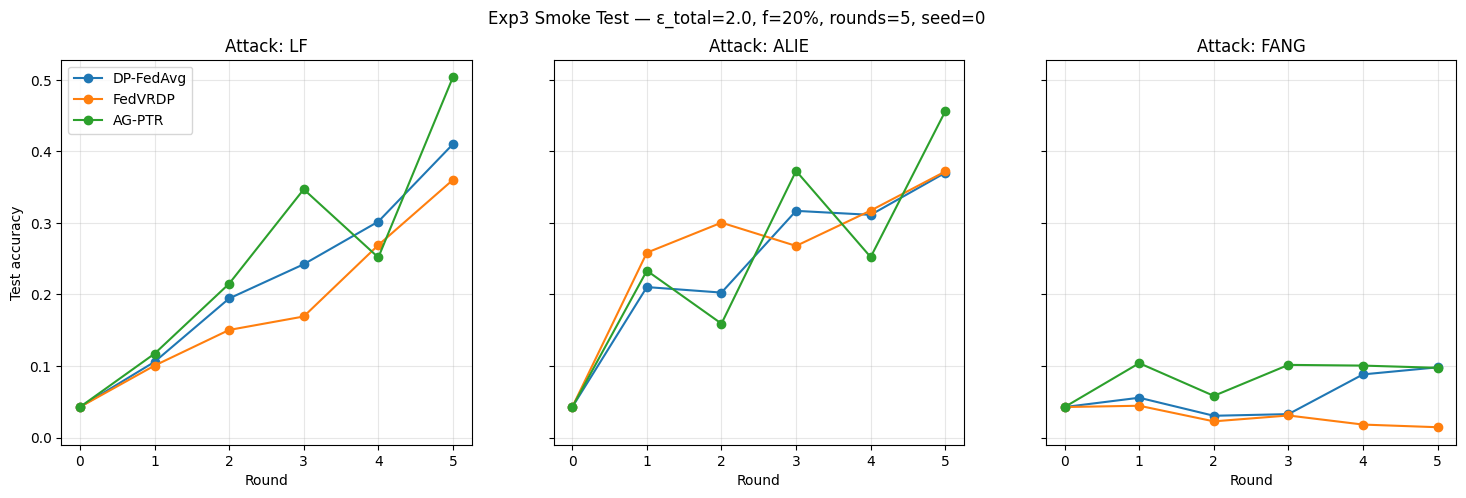


Note: With only a few rounds, AG-PTR may have accept_rate=0 if TAU is high.
If you want to verify the AG-PTR update path in a smoke test, temporarily try TAU=35..45.


In [14]:
# Cell 14 — Experiment 3 SMOKE TEST (FAST)
# Fixed: ε_total=2, f=20%
# Attacks: {LF, ALIE, Fang/AGR(scaled)}
# Plot: accuracy vs rounds (3 panels, one per attack)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 0
eps_total = 2.0
delta = 1e-5
f = 0.20

ROUNDS = 5
LOCAL_EPOCHS = 1
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ATTACKS = ["LF", "ALIE", "FANG"]     # You can also use "AGR" here; code treats it the same.
ALIE_Z = 2.0
ALIE_DIR = -1.0

# Fang/AGR strength:
# For f=0.20, keep gamma < 4 to avoid full cancellation/flip.
FANG_GAMMA = 2.0    # try 1.5, 2.0, 3.0

# AG-PTR params
RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1

# Baselines
CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC = 0.3

q = CLIENTS_PER_ROUND / len(clients)

ROUNDS_FULL = 180

sigma_dp_full = find_sigma_for_target_eps_single(eps_total, q, ROUNDS_FULL, delta)
eps_dp_full = epsilon_from_sigma_single(sigma_dp_full, q, ROUNDS_FULL, delta)

sel_factor = 2.0
sigma_rel_full = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS_FULL, delta, sel_factor=sel_factor)
sigma_sel_full = sel_factor * sigma_rel_full
eps_ag_full = epsilon_from_sigma_two(sigma_sel_full, sigma_rel_full, q, ROUNDS_FULL, delta)

eps_dp_smoke = epsilon_from_sigma_single(sigma_dp_full, q, ROUNDS, delta)
eps_ag_smoke = epsilon_from_sigma_two(sigma_sel_full, sigma_rel_full, q, ROUNDS, delta)

print("Using FULL-run sigmas (computed for 180 rounds):")
print("  DP sigma:", sigma_dp_full, "| eps(180)≈", eps_dp_full, "| eps(smoke)≈", eps_dp_smoke)
print("  AG sigmas sel/rel:", sigma_sel_full, sigma_rel_full, "| eps(180)≈", eps_ag_full, "| eps(smoke)≈", eps_ag_smoke)
print(f"Fixed f={f}, attacks={ATTACKS}, Fang/AGR gamma={FANG_GAMMA}")

METHODS = ["DP-FedAvg", "FedVRDP", "AG-PTR"]
curves = {atk: {} for atk in ATTACKS}
rows = []

for atk in ATTACKS:
    print("\n==============================")
    print("Smoke test attack:", atk)
    print("==============================")

    r_dp, c_dp = train_dp_fedavg_robust(
        seed, eps_total, f, sigma_dp_full, delta=delta,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        clip_C=CLIP_C_DP,
        attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        fang_gamma=FANG_GAMMA,
        return_curve=True, record_every=1
    )

    r_vr, c_vr = train_fedvrdp_robust(
        seed, eps_total, f, sigma_dp_full, delta=delta,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        clip_C=CLIP_C_VR, k_frac=K_FRAC,
        attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        fang_gamma=FANG_GAMMA,
        return_curve=True, record_every=1
    )

    r_ag, c_ag, ar_ag = train_ag_ptr(
        seed, eps_total, f,
        sigma_sel_full, sigma_rel_full, delta=delta,
        rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
        lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
        rho=RHO, tau=TAU,
        R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
        attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
        fang_gamma=FANG_GAMMA,
        allow_zero=False,
        return_curve=True, record_every=1
    )

    curves[atk]["DP-FedAvg"] = (r_dp, c_dp)
    curves[atk]["FedVRDP"]   = (r_vr, c_vr)
    curves[atk]["AG-PTR"]    = (r_ag, c_ag)

    rows.append({
        "attack": atk,
        "dp_fedavg_final_acc": float(c_dp[-1]),
        "fedvrdp_final_acc": float(c_vr[-1]),
        "agptr_final_acc": float(c_ag[-1]),
        "agptr_accept_rate": float(ar_ag)
    })

df_smoke = pd.DataFrame(rows)
display(df_smoke)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, atk in enumerate(ATTACKS):
    ax = axes[i]
    r_dp, c_dp = curves[atk]["DP-FedAvg"]
    r_vr, c_vr = curves[atk]["FedVRDP"]
    r_ag, c_ag = curves[atk]["AG-PTR"]

    ax.plot(r_dp, c_dp, marker="o", label="DP-FedAvg")
    ax.plot(r_vr, c_vr, marker="o", label="FedVRDP")
    ax.plot(r_ag, c_ag, marker="o", label="AG-PTR")

    ax.set_title(f"Attack: {atk}")
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Test accuracy")
axes[0].legend()
plt.suptitle(f"Exp3 Smoke Test — ε_total={eps_total}, f=20%, rounds={ROUNDS}, seed={seed}")
plt.show()

DP-FedAvg/FedVRDP sigma: 0.9723217465539842 achieved eps≈ 1.9999999999999973
AG-PTR sigma_sel / sigma_rel: 1.965902445173369 0.9829512225866845 achieved eps≈ 1.999999999999998
AG-PTR params: rho=0.79, tau=55, R_pub_avg=8, pub_batch=20, pub_scale=0.1
Attacker: ALIE const-z=2.0, dir=-1.0


AG-PTR f=60%: 100%|██████████| 180/180 [02:48<00:00,  1.07it/s]


Saved exp2_seedwise.csv
Saved exp2_summary.csv


,f,seed_mean,seed_std,dp_fedavg_acc_mean,dp_fedavg_acc_std,fedvrdp_acc_mean,fedvrdp_acc_std,agptr_acc_mean,agptr_acc_std,agptr_accept_rate_mean,agptr_accept_rate_std
0,0.00,1.0,1.0,0.802233,0.005977,0.823167,0.005877,0.776467,0.003197,0.725926,0.036147
1,0.10,1.0,1.0,0.760733,0.002673,0.793367,0.013717,0.765033,0.008937,0.687037,0.046259
2,0.20,1.0,1.0,0.650100,0.025270,0.722500,0.016212,0.751700,0.004158,0.561111,0.072860
3,0.30,1.0,1.0,0.448100,0.066234,0.473600,0.030837,0.738667,0.007447,0.329630,0.097235
4,0.40,1.0,1.0,0.241800,0.008350,0.263200,0.023503,0.734767,0.004626,0.174074,0.022453
5,0.49,1.0,1.0,0.184500,0.006338,0.107833,0.007247,0.601700,0.021863,0.029630,0.003208
6,0.60,1.0,1.0,0.130300,0.044105,0.099367,0.001097,0.131133,0.044312,0.005556,0.000000


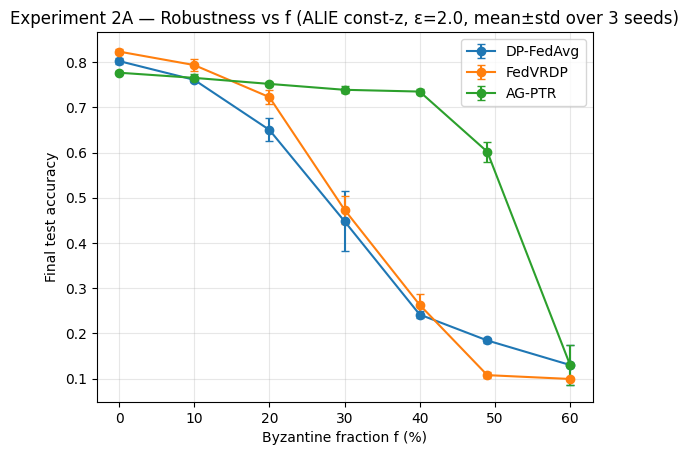

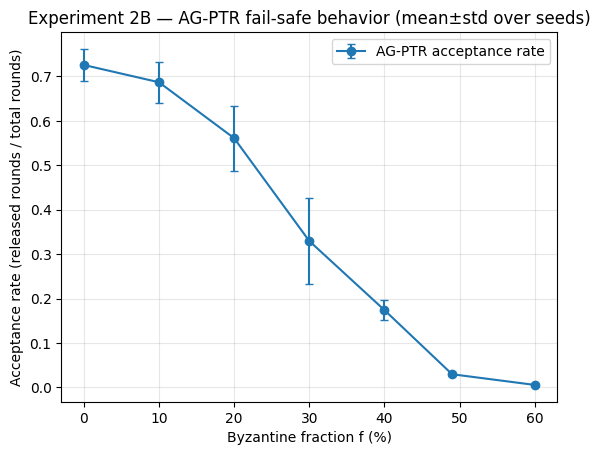

,f,seed_mean,seed_std,dp_fedavg_acc_mean,dp_fedavg_acc_std,fedvrdp_acc_mean,fedvrdp_acc_std,agptr_acc_mean,agptr_acc_std,agptr_accept_rate_mean,agptr_accept_rate_std
0,0.00,1.0,1.0,0.802233,0.005977,0.823167,0.005877,0.776467,0.003197,0.725926,0.036147
1,0.10,1.0,1.0,0.760733,0.002673,0.793367,0.013717,0.765033,0.008937,0.687037,0.046259
2,0.20,1.0,1.0,0.650100,0.025270,0.722500,0.016212,0.751700,0.004158,0.561111,0.072860
3,0.30,1.0,1.0,0.448100,0.066234,0.473600,0.030837,0.738667,0.007447,0.329630,0.097235
4,0.40,1.0,1.0,0.241800,0.008350,0.263200,0.023503,0.734767,0.004626,0.174074,0.022453
5,0.49,1.0,1.0,0.184500,0.006338,0.107833,0.007247,0.601700,0.021863,0.029630,0.003208
6,0.60,1.0,1.0,0.130300,0.044105,0.099367,0.001097,0.131133,0.044312,0.005556,0.000000


In [ ]:
# Cell 15 — FULL Experiment 3: Attack diversity @ fixed ε and f (with scaled Fang/AGR)

seed_list = [0, 1, 2]
eps_total = 2.0
delta = 1e-5
f = 0.20

ROUNDS = 180
LOCAL_EPOCHS = 10
BATCH_SIZE = 10

LR0 = 0.125
LR_DECAY = 0.99
MOMENTUM = 0.5

ATTACKS = ["LF", "ALIE", "FANG"]   # You can switch "FANG"->"AGR" if you prefer naming
ALIE_Z = 2.0
ALIE_DIR = -1.0

FANG_GAMMA = 2.0   # keep <4 for f=0.2

RHO = 0.79
TAU = 55
R_PUB_AVG = 8
PUB_BATCH = 20
PUB_SCALE = 0.1
PUBLIC_EPOCHS = 1

CLIP_C_DP = 1.0
CLIP_C_VR = 0.5
K_FRAC = 0.30

q = CLIENTS_PER_ROUND / len(clients)

sigma_dp = find_sigma_for_target_eps_single(eps_total, q, ROUNDS, delta)

sel_factor = 2.0
sigma_rel = find_sigma_rel_for_target_eps_two(eps_total, q, ROUNDS, delta, sel_factor=sel_factor)
sigma_sel = sel_factor * sigma_rel

print("sigma_dp:", sigma_dp)
print("sigma_sel/sigma_rel:", sigma_sel, sigma_rel)
print("Fang/AGR gamma:", FANG_GAMMA)

METHODS = ["DP-FedAvg", "FedVRDP", "AG-PTR"]
curves = {atk: {m: [] for m in METHODS} for atk in ATTACKS}

for atk in ATTACKS:
    for seed in seed_list:
        r_dp, c_dp = train_dp_fedavg_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_DP,
            attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            fang_gamma=FANG_GAMMA,
            return_curve=True, record_every=1
        )
        curves[atk]["DP-FedAvg"].append(np.array(c_dp))

        r_vr, c_vr = train_fedvrdp_robust(
            seed, eps_total, f, sigma_dp, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            clip_C=CLIP_C_VR, k_frac=K_FRAC,
            attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            fang_gamma=FANG_GAMMA,
            return_curve=True, record_every=1
        )
        curves[atk]["FedVRDP"].append(np.array(c_vr))

        r_ag, c_ag, ar = train_ag_ptr(
            seed, eps_total, f,
            sigma_sel, sigma_rel, delta=delta,
            rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE,
            lr0=LR0, lr_decay=LR_DECAY, momentum=MOMENTUM,
            rho=RHO, tau=TAU,
            R_pub_avg=R_PUB_AVG, pub_batch=PUB_BATCH, pub_scale=PUB_SCALE, public_epochs=PUBLIC_EPOCHS,
            attack=atk, alie_direction=ALIE_DIR, alie_z=ALIE_Z,
            fang_gamma=FANG_GAMMA,
            allow_zero=False,
            return_curve=True, record_every=1
        )
        curves[atk]["AG-PTR"].append(np.array(c_ag))

results = {}
for atk in ATTACKS:
    results[atk] = {}
    for m in METHODS:
        mat = np.stack(curves[atk][m], axis=0)
        results[atk][m] = {"mean": mat.mean(axis=0), "std": mat.std(axis=0)}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, atk in enumerate(ATTACKS):
    ax = axes[i]
    for m in METHODS:
        mean = results[atk][m]["mean"]
        std  = results[atk][m]["std"]
        ax.plot(r_dp, mean, label=m)
        ax.fill_between(r_dp, mean - std, mean + std, alpha=0.2)
    ax.set_title(f"Attack: {atk}")
    ax.set_xlabel("Round")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Test accuracy")
axes[0].legend()
plt.suptitle(f"Experiment 3 — Attack diversity (ε={eps_total}, f=20%, mean±std over {len(seed_list)} seeds)")
plt.show()